# Training odel for predition of  working capital

1. load dataset

In [1]:
import pandas as pd
data = pd.read_csv("../data/raw_data/projects_dataset.csv")

In [2]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

2. Defining features

In [3]:
X = data[
    [
        "initialInvestment",
        "revenueGrowthRate",
        "inflationRate",
        "marketGrowthIndex",
        "sectorRiskIndex",
        "discountRate"
    ]
]

y = data["workingCapitalRatio"]

3. Train Model

In [4]:
# from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

# model = RandomForestRegressor(n_estimators=100)
# model.fit(X_train, y_train)

In [24]:
from xgboost.callback import EarlyStopping
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4, # 4->3
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    early_stopping_rounds=20,
    reg_alpha=0.5,          # L1 regularization
    reg_lambda=1,         # L2 regularization
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-rmse:0.01712
[1]	validation_0-rmse:0.01668
[2]	validation_0-rmse:0.01626
[3]	validation_0-rmse:0.01586


[4]	validation_0-rmse:0.01549
[5]	validation_0-rmse:0.01537
[6]	validation_0-rmse:0.01505
[7]	validation_0-rmse:0.01472
[8]	validation_0-rmse:0.01443
[9]	validation_0-rmse:0.01434
[10]	validation_0-rmse:0.01409
[11]	validation_0-rmse:0.01400
[12]	validation_0-rmse:0.01392
[13]	validation_0-rmse:0.01385
[14]	validation_0-rmse:0.01359
[15]	validation_0-rmse:0.01352
[16]	validation_0-rmse:0.01328
[17]	validation_0-rmse:0.01308
[18]	validation_0-rmse:0.01303
[19]	validation_0-rmse:0.01284
[20]	validation_0-rmse:0.01264
[21]	validation_0-rmse:0.01259
[22]	validation_0-rmse:0.01240
[23]	validation_0-rmse:0.01222
[24]	validation_0-rmse:0.01206
[25]	validation_0-rmse:0.01192
[26]	validation_0-rmse:0.01178
[27]	validation_0-rmse:0.01164
[28]	validation_0-rmse:0.01151
[29]	validation_0-rmse:0.01140
[30]	validation_0-rmse:0.01129
[31]	validation_0-rmse:0.01119
[32]	validation_0-rmse:0.01108
[33]	validation_0-rmse:0.01099
[34]	validation_0-rmse:0.01089
[35]	validation_0-rmse:0.01081
[36]	validatio

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [25]:
print("Best iteration:", model.best_iteration)

Best iteration: 297


tracking training vs testing errror

In [26]:
results = model.evals_result()

# train_rmse = results['validation_0']['rmse']
test_rmse = results['validation_0']['rmse']

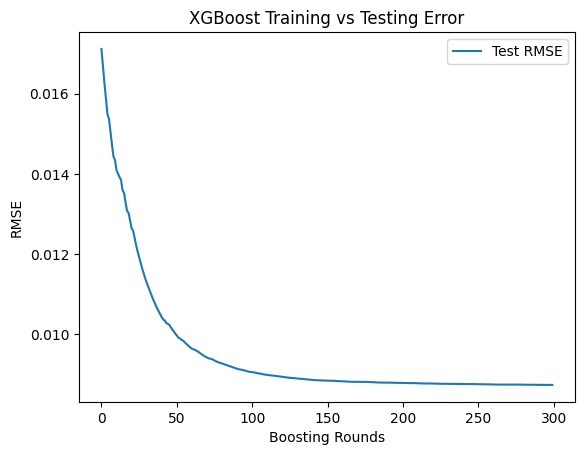

In [27]:
import matplotlib.pyplot as plt

# plt.plot(train_rmse, label='Train RMSE')
plt.plot(test_rmse, label='Test RMSE')
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.title("XGBoost Training vs Testing Error")
plt.legend()
plt.show()

In [28]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("TRAIN PERFORMANCE")
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))

print("\nTEST PERFORMANCE")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))

TRAIN PERFORMANCE
RMSE: 0.007656535358068533
R2: 0.8042619231161323

TEST PERFORMANCE
RMSE: 0.008736348832614331
R2: 0.7520138723851573


4. save model

In [29]:
import joblib
joblib.dump(model, "../model/wc_model.pkl")

['../model/wc_model.pkl']